![head.png](https://github.com/cafawo/FinancialDataAnalytics/blob/master/figures/head.jpg?raw=1)

# Financial Data Analytics in Python

**Prof. Dr. Fabian Woebbeking**</br>
Assistant Professor of Financial Economics

IWH - Leibniz Institute for Economic Research</br>
MLU - Martin Luther University Halle-Wittenberg

fabian.woebbeking@iwh-halle.de

# Homework: data management

You will need a Git/GitHub repository to submit your course deliverables. Consult [**slides.ipynb**](https://github.com/cafawo/FinancialDataAnalytics) for help with the tasks below! If you need further assistance, do not hesitate to open a Q&A at https://github.com/cafawo/FinancialDataAnalytics/discussions

### Task: 

Use Deribit's `"/public/get_tradingview_chart_data"` API endpoint to download historical price data for **"BTC-PERPETUAL"** with a resolution of $60$ minutes, reaching as far back as possible.

Hint: https://docs.deribit.com/#public-get_tradingview_chart_data

In [26]:
import requests
import pandas as pd
import time

url = "https://www.deribit.com/api/v2/public/get_tradingview_chart_data"

params = {
    "instrument_name": "BTC-PERPETUAL",
    "start_timestamp": 1451606400000,  # 2016-01-01
    "end_timestamp":   int(time.time() * 1000),  # now
    "resolution":      "60",
}

response = requests.get(url, params=params)
result = response.json()["result"]

df = pd.DataFrame({
    "datetime": pd.to_datetime(result["ticks"], unit="ms", utc=True),
    "open":     result["open"],
    "high":     result["high"],
    "low":      result["low"],
    "close":    result["close"],
    "volume":   result["volume"],
})

print(df)
df.to_csv("BTC_PERPETUAL_60m.csv", index=False)

df.to_csv("C:/Users/meder/Documents/Uni Halle Studieninhalte/Python/FinancialDataAnalytics/homework/homework_submitted/08-django_BTC_PERPETUAL_60m.csv", index=False)

                      datetime     open     high      low    close      volume
0    2025-12-02 06:00:00+00:00  87027.5  87201.5  86874.0  87121.5  172.821149
1    2025-12-02 07:00:00+00:00  87116.5  87134.0  86901.5  87020.5  242.420860
2    2025-12-02 08:00:00+00:00  87021.0  87046.5  86355.0  86452.5  378.537738
3    2025-12-02 09:00:00+00:00  86452.5  87000.0  86452.0  86787.0  227.381770
4    2025-12-02 10:00:00+00:00  86786.5  87624.5  86780.0  87295.0  282.620211
...                        ...      ...      ...      ...      ...         ...
4996 2026-06-28 10:00:00+00:00  60194.0  60230.0  60010.0  60092.0   81.388540
4997 2026-06-28 11:00:00+00:00  60092.5  60304.5  60048.0  60262.0  113.243512
4998 2026-06-28 12:00:00+00:00  60274.5  60386.5  60129.5  60223.5   63.749548
4999 2026-06-28 13:00:00+00:00  60223.5  60223.5  59910.0  60002.5   98.174667
5000 2026-06-28 14:00:00+00:00  60003.0  60178.5  59965.0  60044.5   22.777075

[5001 rows x 6 columns]


### Task: 

Create a Pandas data frame called "ohlc" with the price data from above. Add the following columns:
```Python
ohlc['timestamp'] = pd.to_datetime(ohlc['ticks'], unit='ms')
ohlc['instrument_name'] = "BTC-PERPETUAL"
ohlc['resolution'] = 60
```

Save `ohlc` into a table of the same name inside a database called "07_datam.db".


In [27]:
print(df.columns)
print(df['datetime'].head())

Index(['datetime', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
0   2025-12-02 06:00:00+00:00
1   2025-12-02 07:00:00+00:00
2   2025-12-02 08:00:00+00:00
3   2025-12-02 09:00:00+00:00
4   2025-12-02 10:00:00+00:00
Name: datetime, dtype: datetime64[ns, UTC]


In [28]:
import pandas as pd

ohlc = pd.DataFrame({
    "timestamp":         pd.to_datetime(result["ticks"], unit="ms", utc=True),
    "open":             result["open"],
    "high":             result["high"],
    "low":              result["low"],
    "close":            result["close"],
    "volume":           result["volume"],
    "instrument_name":  "BTC-PERPETUAL",
    "resolution":       60
})

print(ohlc)

                     timestamp     open     high      low    close  \
0    2025-12-02 06:00:00+00:00  87027.5  87201.5  86874.0  87121.5   
1    2025-12-02 07:00:00+00:00  87116.5  87134.0  86901.5  87020.5   
2    2025-12-02 08:00:00+00:00  87021.0  87046.5  86355.0  86452.5   
3    2025-12-02 09:00:00+00:00  86452.5  87000.0  86452.0  86787.0   
4    2025-12-02 10:00:00+00:00  86786.5  87624.5  86780.0  87295.0   
...                        ...      ...      ...      ...      ...   
4996 2026-06-28 10:00:00+00:00  60194.0  60230.0  60010.0  60092.0   
4997 2026-06-28 11:00:00+00:00  60092.5  60304.5  60048.0  60262.0   
4998 2026-06-28 12:00:00+00:00  60274.5  60386.5  60129.5  60223.5   
4999 2026-06-28 13:00:00+00:00  60223.5  60223.5  59910.0  60002.5   
5000 2026-06-28 14:00:00+00:00  60003.0  60178.5  59965.0  60044.5   

          volume instrument_name  resolution  
0     172.821149   BTC-PERPETUAL          60  
1     242.420860   BTC-PERPETUAL          60  
2     378.537738  

In [29]:
# saving it into a table inside a database
import sqlite3

conn = sqlite3.connect("07_datam.db")  # creates/opens the .db file
ohlc.to_sql("ohlc", conn, if_exists="replace", index=False)  # saves df as table "ohlc"
conn.close()

In [30]:
conn = sqlite3.connect("07_datam.db")
result = pd.read_sql("SELECT * FROM ohlc", conn)
conn.close()
print(result)

                      timestamp     open     high      low    close  \
0     2025-12-02 06:00:00+00:00  87027.5  87201.5  86874.0  87121.5   
1     2025-12-02 07:00:00+00:00  87116.5  87134.0  86901.5  87020.5   
2     2025-12-02 08:00:00+00:00  87021.0  87046.5  86355.0  86452.5   
3     2025-12-02 09:00:00+00:00  86452.5  87000.0  86452.0  86787.0   
4     2025-12-02 10:00:00+00:00  86786.5  87624.5  86780.0  87295.0   
...                         ...      ...      ...      ...      ...   
4996  2026-06-28 10:00:00+00:00  60194.0  60230.0  60010.0  60092.0   
4997  2026-06-28 11:00:00+00:00  60092.5  60304.5  60048.0  60262.0   
4998  2026-06-28 12:00:00+00:00  60274.5  60386.5  60129.5  60223.5   
4999  2026-06-28 13:00:00+00:00  60223.5  60223.5  59910.0  60002.5   
5000  2026-06-28 14:00:00+00:00  60003.0  60178.5  59965.0  60044.5   

          volume instrument_name  resolution  
0     172.821149   BTC-PERPETUAL          60  
1     242.420860   BTC-PERPETUAL          60  
2     

### Task: 

Create a Python `class DataHandler` that connects to 07_datam.db. The class should have functions that:
* download and save,
* select and return, and
* display data as a plot (e.g. the last price over time).

Data saved.


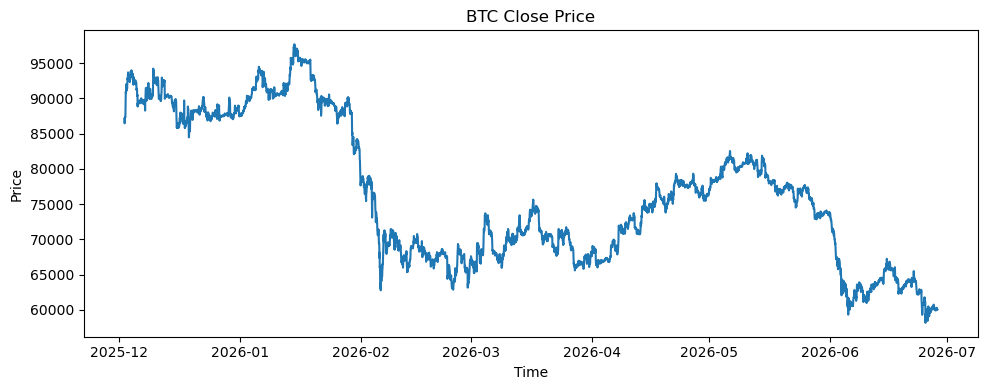

In [36]:
import matplotlib.pyplot as plt
%matplotlib inline

class DataHandler:
    def download_and_save(self, ohlc):
        """Save DataFrame to database."""
        conn = sqlite3.connect("07_datam.db")
        ohlc.to_sql("ohlc", conn, if_exists="replace", index=False)
        conn.close()
        print("Data saved.")

    def select_and_return(self):
        """Load data from database."""
        conn = sqlite3.connect("07_datam.db")
        ohlc = pd.read_sql("SELECT * FROM ohlc", conn)
        conn.close()
        return ohlc

    def plot(self):
        """Plot close price over time."""
        ohlc = self.select_and_return()
        ohlc["timestamp"] = pd.to_datetime(ohlc["timestamp"]).dt.tz_localize(None)
        plt.figure(figsize=(10, 4))
        plt.plot(ohlc["timestamp"], ohlc["close"])
        plt.title("BTC Close Price")
        plt.xlabel("Time")
        plt.ylabel("Price")
        plt.tight_layout()
        plt.show()


# Usage
handler = DataHandler()
handler.download_and_save(ohlc)   # save existing df
handler.plot()                  # display the plot
